# 03 · Démarrage NASA POWER

Ce notebook sert de démonstration de téléchargement léger sur un point au Cameroun.

Remarque: il nécessite une connexion internet fonctionnelle.


## Point d'exemple

On utilise ici Yaoundé comme point de démonstration.


In [1]:
from pathlib import Path
from agrometflow.climate.power import PowerDownloader

output_dir = Path("training_outputs/power")
output_dir.mkdir(parents=True, exist_ok=True)

dl = PowerDownloader(verbose=True)

In [9]:
variables = [
    ("T2M_MAX", "TMAX"),
    ("T2M_MIN", "TMIN"),
    ("PRECTOTCORR", "PR"),
]

dl.download(
    start_date="1991-01-01",
    end_date="2020-12-31",
    variables=variables,
    points=[(9.3360,   13.3700)],
    output_dir=output_dir,
)

[INFO] 2026-04-06 21:18:53 — Fetching POWER data for (9.336, 13.37)
[INFO] 2026-04-06 21:18:56 — Data saved to training_outputs/power/power_19910101_20201231.csv


In [10]:
power_df = dl.extract(variables=["TMAX", "TMIN", "PR"])
power_df.head(10)

,Date,lat,lon,TMAX,TMIN,PR
0,1991-01-01,9.336,13.37,31.39,16.64,0.0
1,1991-01-02,9.336,13.37,32.68,17.15,0.0
2,1991-01-03,9.336,13.37,34.67,17.87,0.0
3,1991-01-04,9.336,13.37,35.77,18.83,0.0
4,1991-01-05,9.336,13.37,36.41,19.62,0.0
5,1991-01-06,9.336,13.37,36.97,18.78,0.0
6,1991-01-07,9.336,13.37,36.61,19.32,0.0
7,1991-01-08,9.336,13.37,37.22,19.36,0.0
8,1991-01-09,9.336,13.37,36.56,18.92,0.0
9,1991-01-10,9.336,13.37,37.15,20.12,0.0


## Questions

- Quelles variables sont directement exploitables pour un modèle de culture ?
- Quelles variables manquent encore ?
- Quelle comparaison voudrais-tu faire entre POWER et une station locale ?


## Étape pédagogique 1 - Préparer les données

Objectif:
- partir du tableau journalier avec une date au format `yyyymmdd`
- identifier les colonnes météo (températures, pluie, autres)
- créer des variables de calendrier (année, mois, décade) utilisables pour les agrégations

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# 1) Source des données: on utilise power_df s'il existe déjà dans le notebook
csv_path = Path("training_outputs/power/power_19910101_20201231.csv")
df = pd.read_csv(csv_path)

# 2) Détection de la colonne date
date_candidates = ["Date", "date", "DATE", "yyyymmdd", "YYYYMMDD"]
date_col = next((c for c in date_candidates if c in df.columns), None)
if date_col is None:
    raise ValueError("Aucune colonne date trouvée. Colonnes testées: Date/date/yyyymmdd")

# 3) Conversion de la date (priorité au format yyyymmdd)
df[date_col] = pd.to_datetime(df[date_col].astype(str), format="%Y%m%d", errors="coerce")
if df[date_col].isna().all():
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")

df = df.dropna(subset=[date_col]).sort_values(date_col).reset_index(drop=True)

# 4) Colonnes numériques météo
numeric_cols = df.select_dtypes(include="number").columns.tolist()
meteo_cols = [c for c in numeric_cols if c.lower() not in {"lat", "lon"}]

# 5) Identification de la pluie et des températures
precip_names = {"PR", "PRECIP", "RAIN", "RR", "PRECTOTCORR", "P"}
precip_col = next((c for c in meteo_cols if c.upper() in precip_names), None)

temp_candidates = [c for c in meteo_cols if c.upper() in {"TMAX", "TMIN", "TMEAN", "TAVG", "TMOY", "TEMP"}]
if "TMAX" in df.columns and "TMIN" in df.columns and "TMEAN" not in df.columns:
    df["TMEAN"] = (df["TMAX"] + df["TMIN"]) / 2
    meteo_cols.append("TMEAN")
    if "TMEAN" not in temp_candidates:
        temp_candidates.append("TMEAN")

temp_plot_col = "TMEAN" if "TMEAN" in df.columns else (temp_candidates[0] if temp_candidates else None)

# 6) Variables calendrier
s = df[date_col]
df["year"] = s.dt.year
df["month"] = s.dt.month
df["day"] = s.dt.day
df["decade_in_month"] = np.where(df["day"] <= 10, 1, np.where(df["day"] <= 20, 2, 3))
df["dekad"] = (df["month"] - 1) * 3 + df["decade_in_month"]

# 7) Règle d'agrégation: somme pour pluie, moyenne pour le reste
agg_map = {c: ("sum" if c == precip_col else "mean") for c in meteo_cols}

print("Date utilisée:", date_col)
print("Colonne pluie:", precip_col)
print("Colonne température pour les graphiques:", temp_plot_col)
print("Colonnes agrégées:", meteo_cols)
print(df.head())

Date utilisée: Date
Colonne pluie: PR
Colonne température pour les graphiques: TMEAN
Colonnes agrégées: ['TMAX', 'TMIN', 'PR', 'TMEAN']
        Date   TMAX   TMIN   PR    lat    lon   TMEAN  year  month  day  \
0 1991-01-01  31.39  16.64  0.0  9.336  13.37  24.015  1991      1    1   
1 1991-01-02  32.68  17.15  0.0  9.336  13.37  24.915  1991      1    2   
2 1991-01-03  34.67  17.87  0.0  9.336  13.37  26.270  1991      1    3   
3 1991-01-04  35.77  18.83  0.0  9.336  13.37  27.300  1991      1    4   
4 1991-01-05  36.41  19.62  0.0  9.336  13.37  28.015  1991      1    5   

   decade_in_month  dekad  
0                1      1  
1                1      1  
2                1      1  
3                1      1  
4                1      1  


In [12]:
df.head()

,Date,TMAX,TMIN,PR,lat,lon,TMEAN,year,month,day,decade_in_month,dekad
0,1991-01-01,31.39,16.64,0.0,9.336,13.37,24.015,1991,1,1,1,1
1,1991-01-02,32.68,17.15,0.0,9.336,13.37,24.915,1991,1,2,1,1
2,1991-01-03,34.67,17.87,0.0,9.336,13.37,26.270,1991,1,3,1,1
3,1991-01-04,35.77,18.83,0.0,9.336,13.37,27.300,1991,1,4,1,1
4,1991-01-05,36.41,19.62,0.0,9.336,13.37,28.015,1991,1,5,1,1


## Étape pédagogique 2 - Moyennes décadaires (et somme pluie)

Dans cette étape:
- on calcule les statistiques **par décade pour chaque année**
- puis on calcule la **climatologie décadaire** (moyenne de toutes les années)
- pour la pluie, la règle est une **somme par décade**

Aperçu décadal par année:


,year,dekad,TMAX,TMIN,PR,TMEAN
0,1991,1,35.543000,18.661000,0.00,27.102000
1,1991,2,36.617000,18.600000,0.00,27.608500
2,1991,3,38.223636,20.230000,0.00,29.226818
3,1991,4,38.636000,20.690000,0.00,29.663000
4,1991,5,40.088000,22.257000,0.00,31.172500
5,1991,6,40.087500,23.816250,0.02,31.951875
6,1991,7,39.347000,24.468000,0.05,31.907500
7,1991,8,39.688000,26.134000,0.87,32.911000
8,1991,9,40.528182,25.238182,0.00,32.883182
9,1991,10,36.233000,25.230000,21.14,30.731500


Aperçu climatologie décadaire (moyenne interannuelle):


,dekad,year,TMAX,TMIN,PR,TMEAN
0,1,2005.5,35.603833,17.632867,0.000333,26.618350
1,2,2005.5,36.143033,17.845333,0.000000,26.994183
2,3,2005.5,37.360515,19.336606,0.009000,28.348561
3,4,2005.5,38.252567,20.355533,0.039667,29.304050
4,5,2005.5,38.744900,21.120833,0.066000,29.932867
5,6,2005.5,39.822500,22.841495,0.092000,31.331998
6,7,2005.5,40.162167,23.775433,0.245000,31.968800
7,8,2005.5,40.096767,24.757433,1.294000,32.427100
8,9,2005.5,40.696636,25.215212,1.075667,32.955924
9,10,2005.5,39.843567,26.066967,9.174000,32.955267


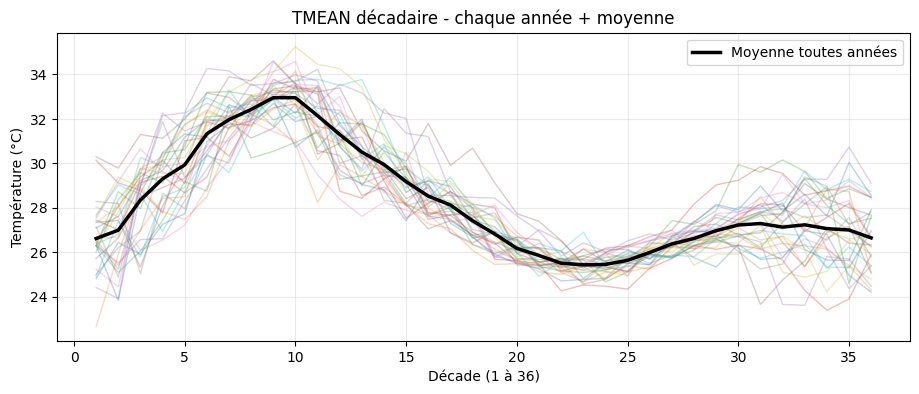

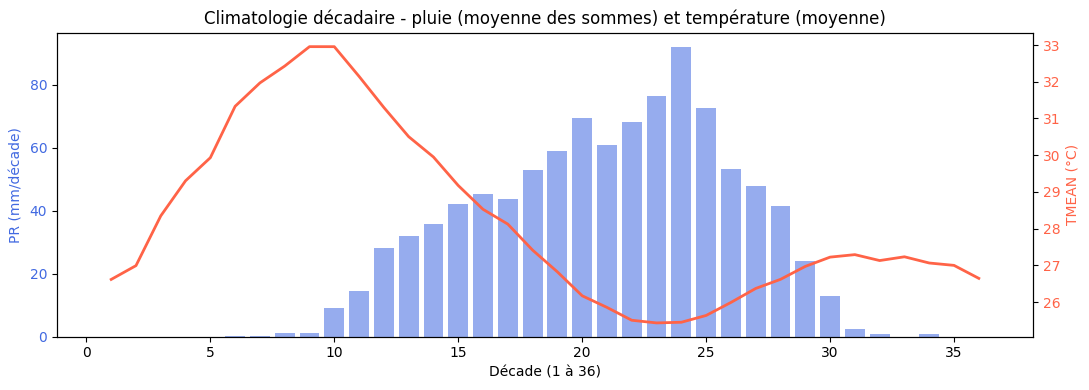

In [13]:
# Agrégation décadaire par année
# Règle: pluie en SOMME par décade et autres variables en MOYENNE
decadal_year = (
    df.groupby(["year", "dekad"], as_index=False)
      .agg(agg_map)
      .sort_values(["year", "dekad"])
)

# Climatologie décadaire (ensemble des années)
# Règle demandée: MOYENNE interannuelle de chaque décade,
# y compris pour la pluie (moyenne des sommes décadaires annuelles)
decadal_all_years = (
    decadal_year.groupby("dekad", as_index=False)
               .mean(numeric_only=True)
               .sort_values("dekad")
)

print("Aperçu décadal par année:")
display(decadal_year.head(12))
print("Aperçu climatologie décadaire (moyenne interannuelle):")
display(decadal_all_years.head(12))

# Plot 1: courbes décadaires pour chaque année (température)
if temp_plot_col is not None:
    plt.figure(figsize=(11, 4))
    for year, g in decadal_year.groupby("year"):
        plt.plot(g["dekad"], g[temp_plot_col], alpha=0.30, linewidth=1)
    plt.plot(decadal_all_years["dekad"], decadal_all_years[temp_plot_col], color="black", linewidth=2.5, label="Moyenne toutes années")
    plt.title(f"{temp_plot_col} décadaire - chaque année + moyenne")
    plt.xlabel("Décade (1 à 36)")
    plt.ylabel("Température (°C)")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.show()

# Plot 2: climatologie décadaire pluie + température (barres + courbe)
if (precip_col is not None) and (temp_plot_col is not None):
    fig, ax1 = plt.subplots(figsize=(11, 4))
    ax1.bar(decadal_all_years["dekad"], decadal_all_years[precip_col], color="royalblue", alpha=0.55, label=precip_col)
    ax1.set_xlabel("Décade (1 à 36)")
    ax1.set_ylabel(f"{precip_col} (mm/décade)", color="royalblue")
    ax1.tick_params(axis="y", labelcolor="royalblue")

    ax2 = ax1.twinx()
    ax2.plot(decadal_all_years["dekad"], decadal_all_years[temp_plot_col], color="tomato", linewidth=2, label=temp_plot_col)
    ax2.set_ylabel(f"{temp_plot_col} (°C)", color="tomato")
    ax2.tick_params(axis="y", labelcolor="tomato")

    plt.title("Climatologie décadaire - pluie (moyenne des sommes) et température (moyenne)")
    fig.tight_layout()
    plt.show()

## Étape pédagogique 3 - Agrégation mensuelle

Ici on calcule:
- une série mensuelle **par année**
- une climatologie mensuelle **toutes années confondues**
- pluie en somme mensuelle, températures et autres en moyenne

Aperçu mensuel par année:


,year,month,TMAX,TMIN,PR,TMEAN
0,1991,1,36.840645,19.198065,0.00,28.019355
1,1991,2,39.569286,22.142857,0.02,30.856071
2,1991,3,39.876129,25.278710,0.92,32.577419
3,1991,4,35.878000,25.414667,87.66,30.646333
4,1991,5,32.629677,24.146129,170.08,28.387903
5,1991,6,31.846333,23.542000,125.53,27.694167
6,1991,7,29.012581,22.080645,176.77,25.546613
7,1991,8,27.865806,21.682581,259.69,24.774194
8,1991,9,29.670000,22.467333,157.77,26.068667
9,1991,10,29.857419,21.806774,84.23,25.832097


Aperçu climatologie mensuelle:


,month,year,TMAX,TMIN,PR,TMEAN
0,1,2005.5,36.401108,18.305957,0.009333,27.353532
1,2,2005.5,38.890152,21.352262,0.197667,30.121207
2,3,2005.5,40.330720,24.603097,2.614667,32.466909
3,4,2005.5,38.298578,25.968489,51.891667,32.133533
4,5,2005.5,34.847183,24.862667,110.100000,29.854925
5,6,2005.5,32.424189,23.621244,142.143000,28.022717
6,7,2005.5,30.015376,22.526204,189.528667,26.270790
7,8,2005.5,28.801935,22.126570,236.869667,25.464253
8,9,2005.5,29.578433,22.422789,173.850000,26.000611
9,10,2005.5,31.477914,22.419957,78.441667,26.948935


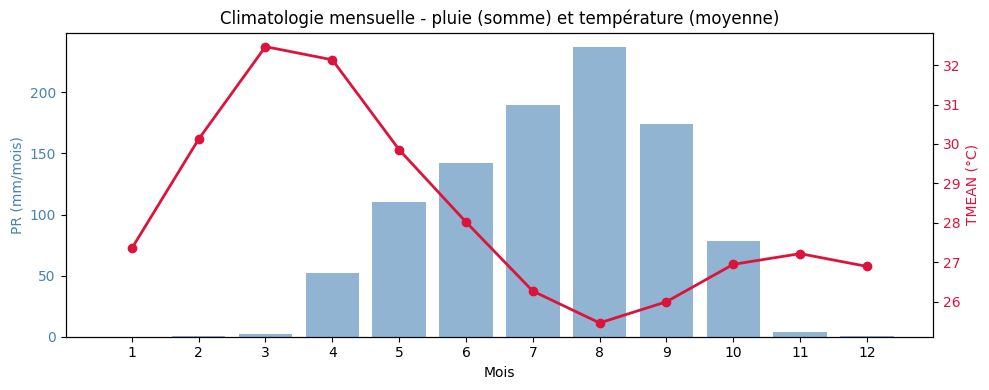

In [14]:
monthly_year = (
    df.groupby(["year", "month"], as_index=False)
      .agg(agg_map)
      .sort_values(["year", "month"])
)

monthly_all_years = (
    monthly_year.groupby("month", as_index=False)
               .mean(numeric_only=True)
               .sort_values("month")
)

print("Aperçu mensuel par année:")
display(monthly_year.head(12))
print("Aperçu climatologie mensuelle:")
display(monthly_all_years)

if (precip_col is not None) and (temp_plot_col is not None):
    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax1.bar(monthly_all_years["month"], monthly_all_years[precip_col], color="steelblue", alpha=0.6)
    ax1.set_xlabel("Mois")
    ax1.set_ylabel(f"{precip_col} (mm/mois)", color="steelblue")
    ax1.tick_params(axis="y", labelcolor="steelblue")
    ax1.set_xticks(range(1, 13))

    ax2 = ax1.twinx()
    ax2.plot(monthly_all_years["month"], monthly_all_years[temp_plot_col], color="crimson", marker="o", linewidth=2)
    ax2.set_ylabel(f"{temp_plot_col} (°C)", color="crimson")
    ax2.tick_params(axis="y", labelcolor="crimson")

    plt.title("Climatologie mensuelle - pluie (somme) et température (moyenne)")
    fig.tight_layout()
    plt.show()

## Étape pédagogique 4 - Agrégation annuelle

On passe à l'échelle annuelle:
- pluie en **somme annuelle**
- températures et autres variables en **moyenne annuelle**

Aperçu annuel:


,year,TMAX,TMIN,PR,TMEAN
0,1991,33.292849,21.958685,1068.64,27.625767
1,1992,33.231721,21.284317,903.67,27.258019
2,1993,33.550192,21.813096,951.41,27.681644
3,1994,33.330849,21.576630,1168.69,27.453740
4,1995,32.978712,21.604959,1221.46,27.291836
5,1996,33.360710,21.454781,1070.95,27.407746
6,1997,33.056082,21.637945,1104.12,27.347014
7,1998,34.588767,22.406082,957.02,28.497425
8,1999,34.568219,22.299699,973.36,28.433959
9,2000,34.504344,21.667787,929.61,28.086066


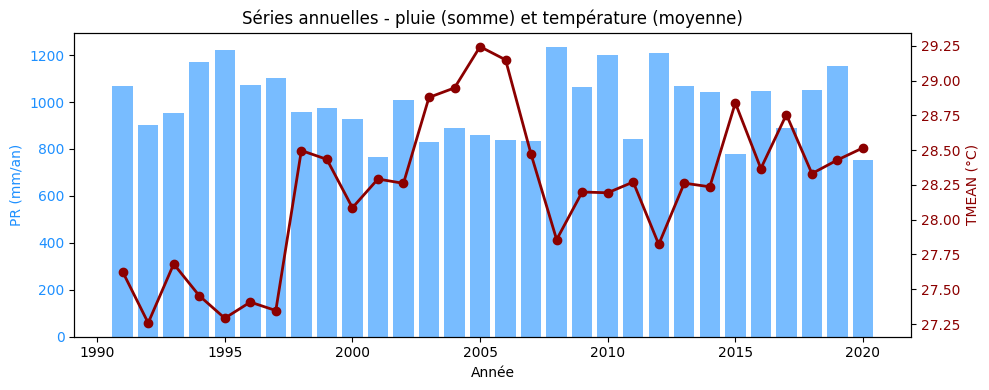

In [15]:
annual = (
    df.groupby("year", as_index=False)
      .agg(agg_map)
      .sort_values("year")
)

print("Aperçu annuel:")
display(annual)

if (precip_col is not None) and (temp_plot_col is not None):
    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax1.bar(annual["year"], annual[precip_col], color="dodgerblue", alpha=0.6)
    ax1.set_xlabel("Année")
    ax1.set_ylabel(f"{precip_col} (mm/an)", color="dodgerblue")
    ax1.tick_params(axis="y", labelcolor="dodgerblue")

    ax2 = ax1.twinx()
    ax2.plot(annual["year"], annual[temp_plot_col], color="darkred", marker="o", linewidth=2)
    ax2.set_ylabel(f"{temp_plot_col} (°C)", color="darkred")
    ax2.tick_params(axis="y", labelcolor="darkred")

    plt.title("Séries annuelles - pluie (somme) et température (moyenne)")
    fig.tight_layout()
    plt.show()

## Étape pédagogique 5 - Courbe ombrothermique (P = 2T)

Principe:
- on utilise la climatologie mensuelle (toutes années)
- on trace `T` et `P/2` sur le même axe (équivalent à la règle P = 2T)
- zones sèches quand `P < 2T`

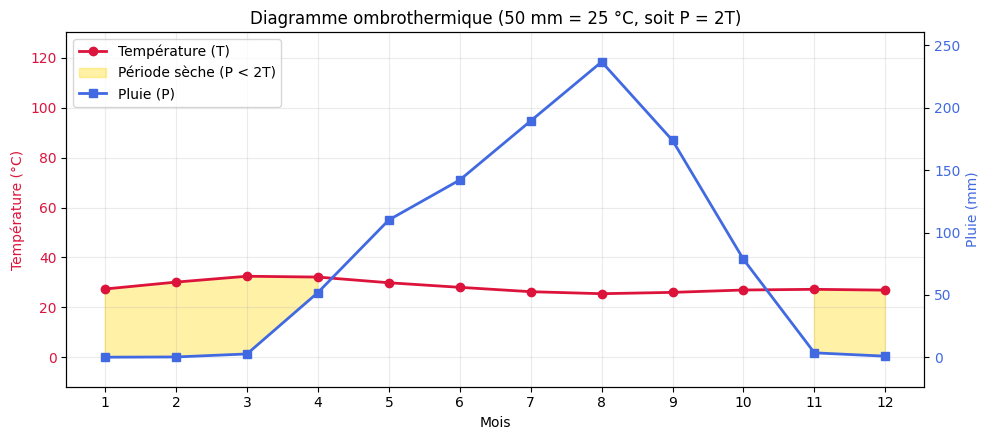

In [16]:
if (precip_col is None) or (temp_plot_col is None):
    raise ValueError("Impossible de tracer la courbe ombrothermique: colonne pluie ou température non trouvée.")

ombro = monthly_all_years[["month", precip_col, temp_plot_col]].copy()

fig, ax = plt.subplots(figsize=(10, 4.5))
ax2 = ax.twinx()

# Données inchangées: T sur l'axe gauche, P sur l'axe droit
ax.plot(ombro["month"], ombro[temp_plot_col], color="crimson", marker="o", linewidth=2, label="Température (T)")
ax2.plot(ombro["month"], ombro[precip_col], color="royalblue", marker="s", linewidth=2, label="Pluie (P)")

# Échelle ombrothermique explicite: 50 mm de pluie correspondent à 25 °C
# soit 2 mm pour 1 °C.
mm_per_deg = 2.0

t_min = float(ombro[temp_plot_col].min())
t_max = float(ombro[temp_plot_col].max())
p_as_t_min = float((ombro[precip_col] / mm_per_deg).min())
p_as_t_max = float((ombro[precip_col] / mm_per_deg).max())

y_min = min(t_min, p_as_t_min)
y_max = max(t_max, p_as_t_max)
margin = max(1.0, 0.1 * (y_max - y_min))

ax.set_ylim(y_min - margin, y_max + margin)
left_min, left_max = ax.get_ylim()
ax2.set_ylim(mm_per_deg * left_min, mm_per_deg * left_max)

# Zones sèches: P < 2T
p_on_temp_scale = ombro[precip_col] / mm_per_deg
dry_mask = ombro[precip_col] < (mm_per_deg * ombro[temp_plot_col])
ax.fill_between(
    ombro["month"],
    p_on_temp_scale,
    ombro[temp_plot_col],
    where=dry_mask,
    color="gold",
    alpha=0.35,
    label="Période sèche (P < 2T)",
)

ax.set_xticks(range(1, 13))
ax.set_xlabel("Mois")
ax.set_ylabel("Température (°C)", color="crimson")
ax2.set_ylabel("Pluie (mm)", color="royalblue")
ax.tick_params(axis="y", labelcolor="crimson")
ax2.tick_params(axis="y", labelcolor="royalblue")
ax.set_title("Diagramme ombrothermique (50 mm = 25 °C, soit P = 2T)")
ax.grid(alpha=0.25)

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper left")

plt.tight_layout()
plt.show()